# Here we try to reduce quantum circuic size by shrinking 6 qubit blocks
We take the block:

and transform it to the 

So, we cut fist double qubit block with 4 U3 and 2 CZ gates. 

Using this shrinking for all qubits allows to cut 1 layer of the brick-wall ciruit. Applying the same techbique further may allow to cut more layers.

In [2]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

import numpy as np
import random
import copy
import time

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

In [3]:
def add_double_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc

def add_double_inverse_cz_block(qc, params, qubits_list):
    pp = params
    qc.u(-pp[12], -pp[14], -pp[13], qubits_list[0])
    qc.u(-pp[15], -pp[17], -pp[16], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[6], -pp[8], -pp[7], qubits_list[0])
    qc.u(-pp[9], -pp[11], -pp[10], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[0], -pp[2], -pp[1], qubits_list[0])
    qc.u(-pp[3], -pp[5], -pp[4], qubits_list[1])
    return qc

def double_cz_op(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op.data

def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el


def estim_func(params, init_circ):
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
      
    return est

def find_alt_params(param_init):
    find = 0
    for i_try in range(40):
        param_0 = []
        for i in range(18):
            param_0.append(random.random() * 2 * PI)
         
        res = minimize(
                    estim_func,
                    param_0,
                    args = (param_init),
                    method = 'SLSQP', 
                    options = {"maxiter":  10000} 
                )
        if res.fun < 0.1:
            break
    
    return res


def find_alt_params(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = double_cz_op(params_init)
    for i in range(n_tries):
        param_0 = np.random.rand(18) * 2 * PI
        res = minimize(
                    estim_func_1,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break

    return min_dev_par


In [12]:
def block_6_circ(par):
    q_2 = qiskit.QuantumCircuit(6)
    
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
  
    
    return q_2

def block_6(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    op = Operator(q_2)
    return op

def reduced_block_6_circ(par):

    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
        
    return q_2


def reduced_block_6(par):
    q_2 = qiskit.QuantumCircuit(6)

    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    
    op = Operator(q_2)
    return op


def double_q_diff_full(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el


def double_q_diff_partial(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    diff = 0 
    for i in range(0,64):
        for j in range(0,1):
            diff = diff + abs(mm.data[i][j]) * abs(mm.data[i][j])
    diff = np.sqrt(diff/64)
    return diff

def estim_func_6_full(params, init_circ):
    test_circ = reduced_block_6(params)
    est = double_q_diff_full(init_circ, test_circ)
    return est

def estim_func_6_partial(params, init_circ):
    test_circ = reduced_block_6(params)
    est = double_q_diff_partial(init_circ, test_circ)
    return est
    
def find_alt_params_6_full(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_full,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

def find_alt_params_6_partial(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_partial,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

In [5]:
def peaked_circuit(n_qubits, qc_depth, hidden, add_string, list_of_switched_qubits, list_of_shifts, prec, n_tries, phi_range):
    
    start_time = time.time()
    n_randon_blocks = int(n_qubits / 2 * qc_depth) #total number of blocks in the first half of the circuit
    params = []

    #Part 1. Creating a ciruit with peak at |0>^n state 
    #create a set of random angles for all blocks in the first half of the circuit
    for i in range(n_randon_blocks):
        pp = []
        for j in range(18):
            #pp.append(random.random() * 2 * PI)
            pp.append(random.random() * phi_range)
        params.append(pp)
    
    q_reg = Q_R(n_qubits)
    c_reg = C_R(n_qubits)
    qc_rand = qiskit.QuantumCircuit(q_reg, c_reg)

    #Creating a list of qubit pairs
    block_n = 0
    qubits_pairs_order = []
    for i in range(qc_depth):
        if i % 2 == 0:
            for i_q in range(int(n_qubits / 2)):
                qubits_pairs_order.append([i_q * 2, i_q * 2 + 1])
                block_n = block_n + 1
        if i % 2 == 1:
            qubits_pairs_order.append([0, n_qubits - 1])
            block_n = block_n + 1
            for i_q in range(int(n_qubits / 2) - 1):
                qubits_pairs_order.append([i_q * 2 + 1, i_q * 2 + 2])
                block_n = block_n + 1
    #creating first half of the circuit. The random brick-wall circuit
    for i_block in range(block_n):
        qc_rand = add_double_cz_block(qc_rand, params[i_block], qubits_pairs_order[i_block])

    #creating the second half of the circuit. The mirror, or inverse circuit
    #Depending on the 'hidden' parameter, blocks modification is either used or not
    block_dev = []
    for i_block in range(block_n):
        param_init = params[n_randon_blocks - 1 - i_block]
        if hidden == 1:
            res_min = find_alt_params(param_init, prec, n_tries)
            new_params = res_min.x
            qc_rand = add_double_inverse_cz_block(qc_rand, new_params, qubits_pairs_order[n_randon_blocks - 1 - i_block])
        else:
            qc_rand = add_double_inverse_cz_block(qc_rand, param_init, qubits_pairs_order[n_randon_blocks - 1 - i_block])
            
    #add measurements of each qubits at the end
    for i in range(n_qubits):
        qc_rand.measure(i,i)
      
    
    #Part 2
    #here I take the random circuit and merge all double U-gates into single U gate
    #merging the double U gates
    circuit_len = len(qc_rand.data)
    instructions = []
    for instruction, qargs, cargs in qc_rand:
        instructions.append((instruction, qargs, cargs))
    
    delete_list = []
    modify_list = []
    params_list = []
    #Find all the double u gates and find parameters for merged U gates
    for i_q in range(n_qubits):
        prev_gate = 0
        for i_inst in range(circuit_len):
            q_num = []
            q_num.append(instructions[i_inst][1][0]._index)
            qibits_in_gate = len(instructions[i_inst][1])
            if qibits_in_gate == 2:
                q_num.append(instructions[i_inst][1][1]._index)
            gate_name = instructions[i_inst][0].name
            #print(q_num)
            if i_q in q_num:
                if gate_name == 'cz':
                    prev_gate = 0
                else:
                    if gate_name == 'u' and prev_gate == 0:
                        prev_gate = 1
                        last_u = i_inst
                    else:
                        if gate_name == 'u' and prev_gate == 1:
                            #print('found')
                            delete_list.append(last_u)
                            modify_list.append(i_inst)
                            qc_temp = qiskit.QuantumCircuit(1)
                            par = instructions[last_u][0].params
                            qc_temp.u(par[0], par[1], par[2], 0)
                            par = instructions[i_inst][0].params
                            qc_temp.u(par[0], par[1], par[2], 0)
                            qc_temp.draw('mpl')
                            qc_temp_tr = transpile(qc_temp, basis_gates = ['u3','cx'])
                            if qc_temp_tr.size() == 0:
                                params_2 = [0, 0, 0]
                            else:
                                instruction_new = qc_temp_tr.data[0]
                                params_2 = instruction_new[0].params
                            params_list.append(params_2)
                            prev_gate = 0
             
    #Create a new circuit with merged u-gates
    mod_instr = []
    mod_instr = copy.deepcopy(instructions)
    for i_inst in range(len(modify_list)):
        mod_instr[modify_list[i_inst]][0].params = params_list[i_inst]
    for index in sorted(delete_list, reverse=True):
        mod_instr.pop(index)
    qc_merged = qiskit.QuantumCircuit(n_qubits, n_qubits)
    for i_instr in range(len(mod_instr) - n_qubits):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])
    for i in range(n_qubits):
        qc_merged.measure(i,i) 
    
    #Part 3
    #here I convert '0000...00' peaked state to some predefined peaked state with ones and zeroes like '11010001..01'
    #I move x gates from the beginning of the circuit to some chosen position
    if add_string == 1:
        circuit_len = len(qc_merged.data)
        instructions_m = []
        for instruction, qargs, cargs in qc_merged:
            instructions_m.append((instruction, qargs, cargs))
        #Creating a "true" copy of the instructions set
        mod_instr_1 = []
        mod_instr_1 = copy.deepcopy(instructions_m)
            

        for ii_q in range(len(list_of_switched_qubits)):
            i_q = list_of_switched_qubits[ii_q]
            #Getting the lists of modified gates for given modfied qubit
            if i_q == 0:
                involved_qubits = [n_qubits - 1, 1]
            else:
                if i_q == n_qubits - 1:
                    involved_qubits = [n_qubits - 2, 0]
                else: 
                    involved_qubits = [i_q - 1, i_q + 1]
            
            n_zcs_move = list_of_shifts[ii_q]
            list_of_neighbourong_U_above = []
            list_of_neighbourong_U_below = []
            check_neighbour_below = 0
            check_neighbour_above = 0
            list_of_U = []
            check_neighbour = 0
            curr_cz = 0
            check_neighbour_only = 0
            
            for i_inst in range(circuit_len):
                #get qubits participating in the gate
                q_num = []
                q_num.append(mod_instr_1[i_inst][1][0]._index)
                qibits_in_gate = len(mod_instr_1[i_inst][1])
                if qibits_in_gate == 2:
                    q_num.append(mod_instr_1[i_inst][1][1]._index)
                gate_name = mod_instr_1[i_inst][0].name
                match check_neighbour_only:
                    case 0:
                        if i_q in q_num:
                            if gate_name == 'u':
                                list_of_U.append(i_inst)
                            else:
                                if gate_name == 'cz' and curr_cz == n_zcs_move:
                                    if check_neighbour_above == 0 and check_neighbour_below == 0:
                                        break
                                    else:
                                        check_neighbour_only = 1
                                else:
                                    curr_cz = curr_cz + 1
                                    if involved_qubits[0] in q_num:
                                        check_neighbour_above = 1
                                    if involved_qubits[1] in q_num:
                                        check_neighbour_below = 1
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
            
                    case 1:
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
                        if check_neighbour_below == 0 and check_neighbour_above == 0:
                            break
            #modify instructions according to the list we get previously
            for i_inst in range(len(list_of_neighbourong_U_below)):
                params_new = mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params
                params_new_1 =[params_new[0], params_new[1], PI + params_new[2]] 
                mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params = params_new_1
            if n_qubits > 2:
                for i_inst in range(len(list_of_neighbourong_U_above)):
                    params_new = mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params
                    params_new_1 =[params_new[0], params_new[1], PI + params_new[2]]
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
                    mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params = params_new_1
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
            for i_inst in range(len(list_of_U) - 1):
                params_new = mod_instr_1[list_of_U[i_inst]][0].params
                params_new_1 =[params_new[0], PI - params_new[1], PI - params_new[2]] 
                mod_instr_1[list_of_U[i_inst]][0].params = params_new_1
            params_new = mod_instr_1[list_of_U[len(list_of_U) -1]][0].params
            params_new_1 =[PI - params_new[0], params_new[1] - PI, - params_new[2]]
            mod_instr_1[list_of_U[len(list_of_U) -1]][0].params = params_new_1
                
        #Creating a new quantm circuits with modifications   
        qc_merged_1 = qiskit.QuantumCircuit(n_qubits, n_qubits)
        for i_instr in range(len(mod_instr_1) - n_qubits):
            instruction = mod_instr_1[i_instr][0]
            qarg = mod_instr_1[i_instr][1] 
            if len(qarg) == 1:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index], [])
            if len(qarg) == 2:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index, mod_instr_1[i_instr][1][1]._index], [])
        for i in range(n_qubits):
            qc_merged_1.measure(i,i)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Mean elapsed time: {elapsed_time}")
        return qc_merged_1
    else:
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Mean elapsed time: {elapsed_time}")
        return qc_merged    

In [6]:
def func_gates_coordinates_list(qc):
    n_q = qc.num_qubits
    n_g = len(qc.data)
    qubits_coord = []
    for i_q in range(n_q):
        q_coord = []
        for i in range(n_g):
            cur_gate = qc.data[i]
            qubits_number = len(cur_gate[1])
            #Get qubits list for current gate
            q_list = []
            for ii in range(qubits_number):
                q_list.append(cur_gate[1][ii]._index)
            #print(cur_gate[0].name)
            if cur_gate[0].name == 'u' and q_list[0] == i_q:
                q_coord.append(i)
        
        qubits_coord.append(q_coord)
    return qubits_coord
    

In [17]:
def get_block_6_list(block_n, number_of_qubits, qubits_coord):
    q_l = []
    #Getting participating qubits
    for i in range(6):
        q_l.append((block_n * 2 + -2 + i)%number_of_qubits)

    block_6_instr_list = []
    block_6_instr_list.append(qubits_coord[q_l[0]][0])
    block_6_instr_list.append(qubits_coord[q_l[1]][0])
    block_6_instr_list.append(qubits_coord[q_l[2]][0])
    block_6_instr_list.append(qubits_coord[q_l[3]][0])
    block_6_instr_list.append(qubits_coord[q_l[4]][0])
    block_6_instr_list.append(qubits_coord[q_l[5]][0])
    
    block_6_instr_list.append(qubits_coord[q_l[0]][1])
    block_6_instr_list.append(qubits_coord[q_l[1]][1])
    block_6_instr_list.append(qubits_coord[q_l[2]][1])
    block_6_instr_list.append(qubits_coord[q_l[3]][1])
    block_6_instr_list.append(qubits_coord[q_l[4]][1])
    block_6_instr_list.append(qubits_coord[q_l[5]][1])

    block_6_instr_list.append(qubits_coord[q_l[1]][2])
    block_6_instr_list.append(qubits_coord[q_l[2]][2])
    block_6_instr_list.append(qubits_coord[q_l[3]][2])
    block_6_instr_list.append(qubits_coord[q_l[4]][2])

    block_6_instr_list.append(qubits_coord[q_l[1]][3])
    block_6_instr_list.append(qubits_coord[q_l[2]][3])
    block_6_instr_list.append(qubits_coord[q_l[3]][3])
    block_6_instr_list.append(qubits_coord[q_l[4]][3])

    block_6_instr_list.append(qubits_coord[q_l[2]][4])
    block_6_instr_list.append(qubits_coord[q_l[3]][4])

    block_6_instr_list.append(qubits_coord[q_l[2]][5])
    block_6_instr_list.append(qubits_coord[q_l[3]][5])

    block_6_instr_list.append(qubits_coord[q_l[2]][6])
    block_6_instr_list.append(qubits_coord[q_l[3]][6])

    return block_6_instr_list


In [8]:
def get_block_6_circ(block_n, qc, qubits_coord):
    block_angles = []
    number_of_qubits = qc.num_qubits
    block_6_instr_list = get_block_6_list(block_n, number_of_qubits, qubits_coord)
    #print(block_4_instr_list)
    qc_block_6 = qiskit.QuantumCircuit(6)
  
    for i_inst in range(len(block_6_instr_list)):
        cur_gate = qc.data[block_6_instr_list[i_inst]]
        block_angles.append(cur_gate[0].params)

    params = np.array(block_angles).flatten()

    qc_block_6 = block_6_circ(params)
            
    return qc_block_6

def get_block_6_params(block_n, qc, qubits_coord):
    block_angles = []
    number_of_qubits = qc.num_qubits
    block_6_instr_list = get_block_6_list(block_n, number_of_qubits, qubits_coord)
    #print(block_4_instr_list)
    qc_block_6 = qiskit.QuantumCircuit(6)
  
    for i_inst in range(len(block_6_instr_list)):
        cur_gate = qc.data[block_6_instr_list[i_inst]]
        block_angles.append(cur_gate[0].params)

    params = np.array(block_angles).flatten()
        
    return params


### Creeate an ideal peaked circuit 

In [85]:
list_of_switched_qubits = [0] #list of qubits to whose we apply X operator.
list_of_shifts = [1]
n_q = 6
n_l = 4
phi_range = 0.25 * PI
hidden = 0
add_string = 0
prec = 0.005
n_tries = 3
qc = peaked_circuit(n_q, n_l, hidden, add_string, list_of_switched_qubits, list_of_shifts, prec, n_tries, phi_range)


Mean elapsed time: 0.8351333141326904


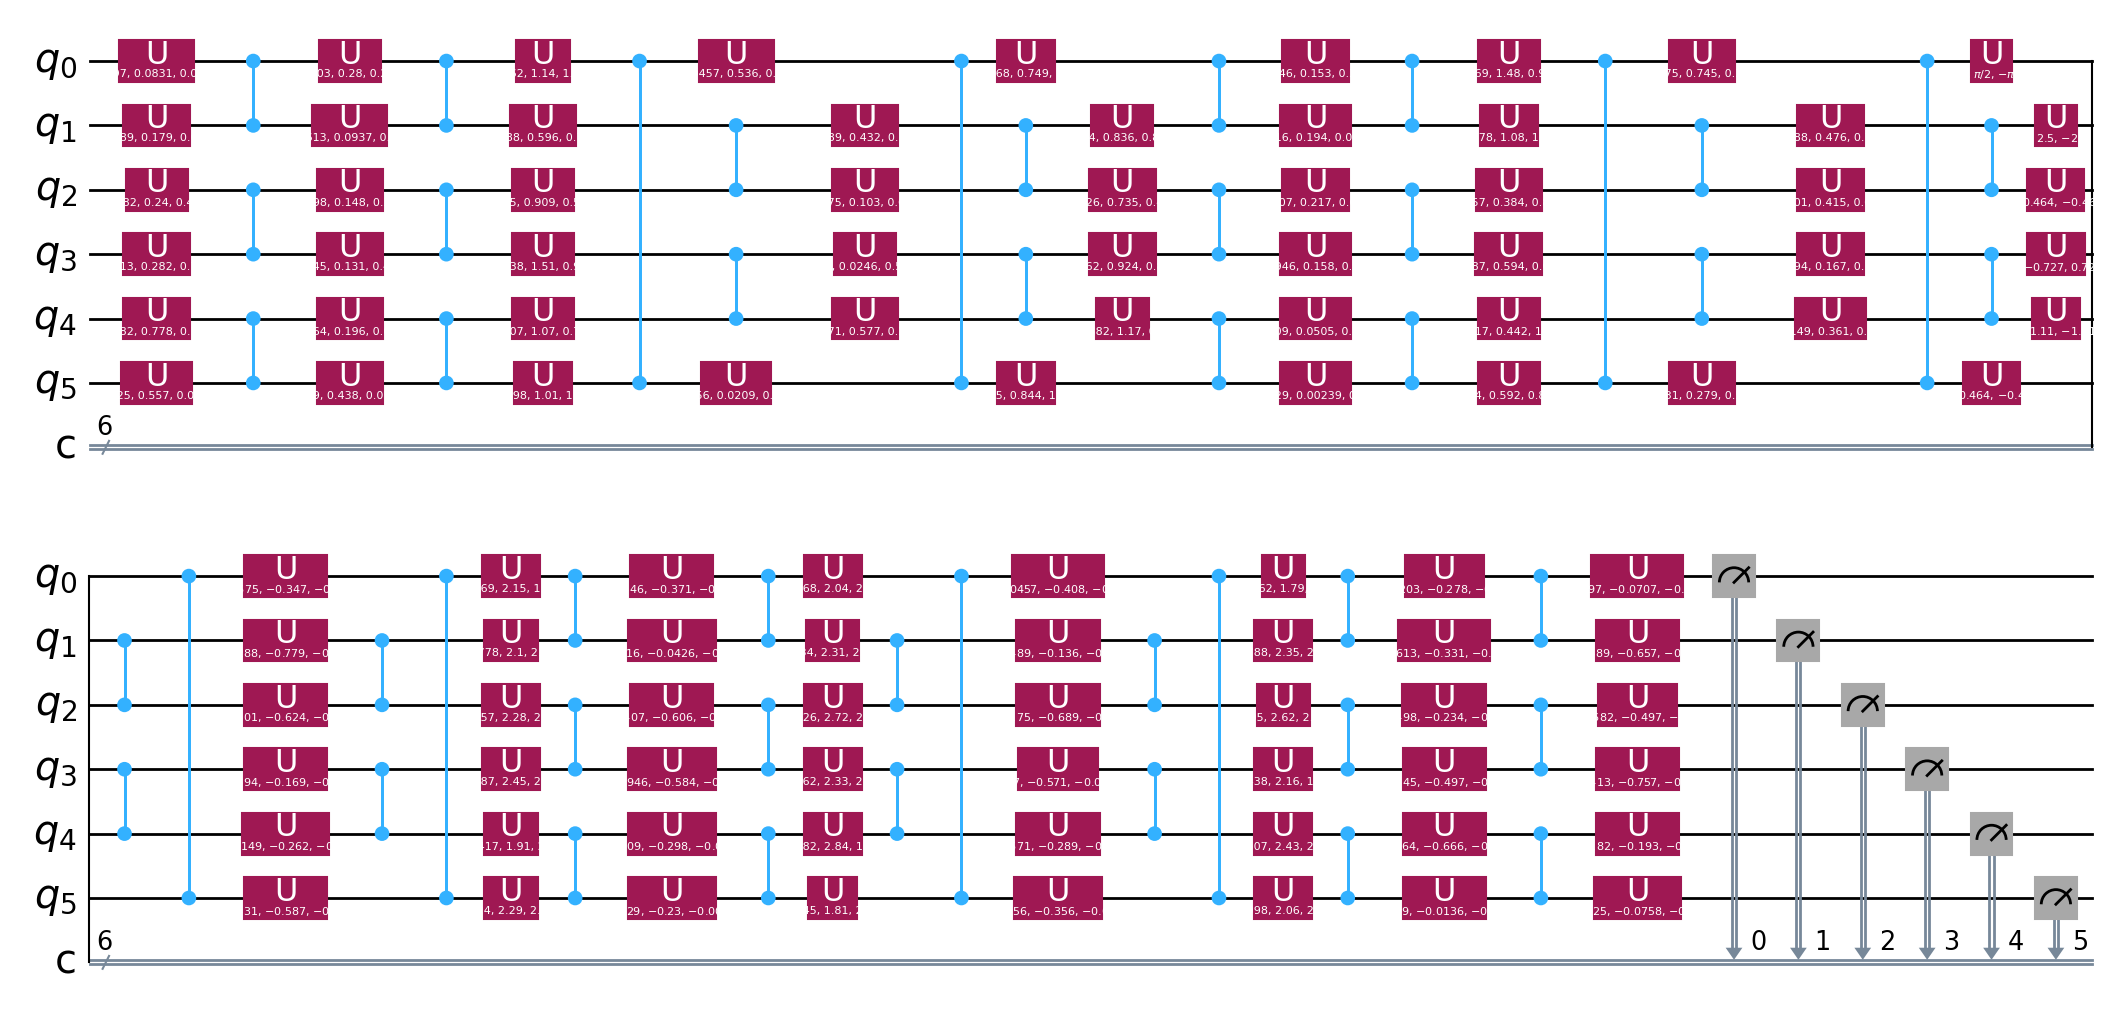

In [95]:

qc.draw('mpl', style={'fontsize': 23}, fold=31)

In [84]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Get the matplotlib figure
fig = circuit_drawer(qc, output='mpl')

# Add a line manually using Matplotlib
#ax = plt.gca()
#ax.plot([0.02, 0.08], [0.05, 0.05], 'r--', linewidth=2)  # example line

# Show updated figure
plt.show()

In [10]:
simulator = AerSimulator()
qc_t = transpile(qc, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
counts

{'00000000': 1000}

In [28]:
block_n = 2
qubits_coord = func_gates_coordinates_list(qc)
qc_block_6 = get_block_6_circ(block_n, qc, qubits_coord)
#qc_block_6.draw('mpl')
#for i in range(len(qc_block)):
#    print(qc_block.data[i])

In [29]:
labeled_qc = QuantumCircuit(qc.qubits, qc.clbits)
for idx, (inst, qargs, cargs) in enumerate(qc.data):
    # Clone the instruction and assign a label
    inst_copy = inst.to_mutable()
    inst_copy.label = f"{idx}"
    labeled_qc.append(inst_copy, qargs, cargs)
#labeled_qc.draw('mpl')

In [109]:
#qc.draw('mpl')
#len(block_angles)

## 6-qubit block modification

In [42]:
prec = 0.005
n_tries = 3
param_init  = get_block_6_params(block_n, qc, qubits_coord)
res_min = find_alt_params_6_partial(param_init, prec, n_tries)
new_params = res_min.x
block_devs = res_min.fun
qc_1 = reduced_block_6_circ(new_params)
#qc_1.draw('mpl')
#block_angles

In [43]:
prec = 0.005
n_tries = 3
param_init  = get_block_6_params(block_n, qc, qubits_coord)
res_min = find_alt_params_6_full(param_init, prec, n_tries)
new_params = res_min.x
block_devs = res_min.fun
qc_2 = reduced_block_6_circ(new_params)
#qc_1.draw('mpl')
#block_angles

In [45]:
simulator = AerSimulator()
qc_block_6.measure_all()
qc_t = transpile(qc_block_6, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
#counts


In [46]:
top_10_MPS = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

000000 000000 000000 000000 = 359              | 000000 000000 000000 000000 = 359
000001 000001 000001 000001 = 96               | 000001 000001 000001 000001 = 96
011000 011000 011000 011000 = 80               | 011000 011000 011000 011000 = 80
010000 010000 010000 010000 = 74               | 010000 010000 010000 010000 = 74
001000 001000 001000 001000 = 65               | 001000 001000 001000 001000 = 65
000110 000110 000110 000110 = 49               | 000110 000110 000110 000110 = 49
000100 000100 000100 000100 = 45               | 000100 000100 000100 000100 = 45
001001 001001 001001 001001 = 21               | 001001 001001 001001 001001 = 21
000111 000111 000111 000111 = 19               | 000111 000111 000111 000111 = 19
011001 011001 011001 011001 = 18               | 011001 011001 011001 011001 = 18


In [50]:
simulator = AerSimulator()
qc_1.measure_all()
qc_t = transpile(qc_1, simulator)
result = simulator.run(qc_t,shots = 1000).result()
counts = result.get_counts(qc_t)
#counts

In [51]:
top_10_MPS = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

000000 000000 000000 = 344              | 000000 000000 000000 = 344
011000 011000 011000 = 95               | 011000 011000 011000 = 95
000001 000001 000001 = 89               | 000001 000001 000001 = 89
010000 010000 010000 = 67               | 010000 010000 010000 = 67
000100 000100 000100 = 66               | 000100 000100 000100 = 66
001000 001000 001000 = 63               | 001000 001000 001000 = 63
000110 000110 000110 = 32               | 000110 000110 000110 = 32
000111 000111 000111 = 32               | 000111 000111 000111 = 32
011001 011001 011001 = 25               | 011001 011001 011001 = 25
000011 000011 000011 = 22               | 000011 000011 000011 = 22


## Layer removal

In [59]:
#Define parameters
prec = 0.0005
n_tries = 3
new_params = []
block_devs = []

qubits_coord = func_gates_coordinates_list(qc)

#Create a copy of initial circuit
circuit_len = len(qc.data)
instructions = []
for instruction, qargs, cargs in qc:
    instructions.append((instruction, qargs, cargs))
mod_instr = []
mod_instr = copy.deepcopy(instructions)

qc_mod = qiskit.QuantumCircuit(n_q)
for i_instr in range(len(mod_instr) - n_q):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])

number_of_qubits = qc_mod.num_qubits

#Blocks replacement
for i_block in range(0, int(number_of_qubits/2)): #
    block_6_instr_list = get_block_6_list(i_block, number_of_qubits, qubits_coord) # get the list of instructions to be modified
    block_angles  = get_block_6_params(i_block, qc_mod, qubits_coord) # get the parameters of the block for modification
    res_min = find_alt_params_6_partial(block_angles, prec, n_tries) #calculate new parameters
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)

    #extract all instructions from circuit and copy them into the new instruction array
    circuit_len = len(qc_mod.data)
    instructions = []
    for instruction, qargs, cargs in qc_mod:
        instructions.append((instruction, qargs, cargs))
    mod_instr = []
    mod_instr = copy.deepcopy(instructions)

    for i_instr in range (0,2):
        mod_instr[block_6_instr_list[i_instr]][0].params = [new_params[i_block][i_instr * 3 + 0], new_params[i_block][i_instr * 3 + 1], new_params[i_block][i_instr * 3 + 2]]
    mod_instr[block_6_instr_list[2]][0].params = [0, 0, 0]
    mod_instr[block_6_instr_list[3]][0].params = [0, 0, 0]
    for i_instr in range (2,6):
        mod_instr[block_6_instr_list[i_instr + 2]][0].params = [new_params[i_block][i_instr * 3 + 0], new_params[i_block][i_instr * 3 + 1], new_params[i_block][i_instr * 3 + 2]]
    mod_instr[block_6_instr_list[8]][0].params = [0, 0, 0]
    mod_instr[block_6_instr_list[9]][0].params = [0, 0, 0]
    for i_instr in range (6, 22):
        mod_instr[block_6_instr_list[i_instr + 4]][0].params = [new_params[i_block][i_instr * 3 + 0], new_params[i_block][i_instr * 3 + 1], new_params[i_block][i_instr * 3 + 2]]
    
    #create a new circuit and put there modifed instructions
    qc_mod = qiskit.QuantumCircuit(number_of_qubits)
    for i_instr in range(len(mod_instr)):
        instruction = mod_instr[i_instr][0]
        qarg = mod_instr[i_instr][1] 
        if len(qarg) == 1:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index], [])
        if len(qarg) == 2:
            qc_mod.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])

    
    

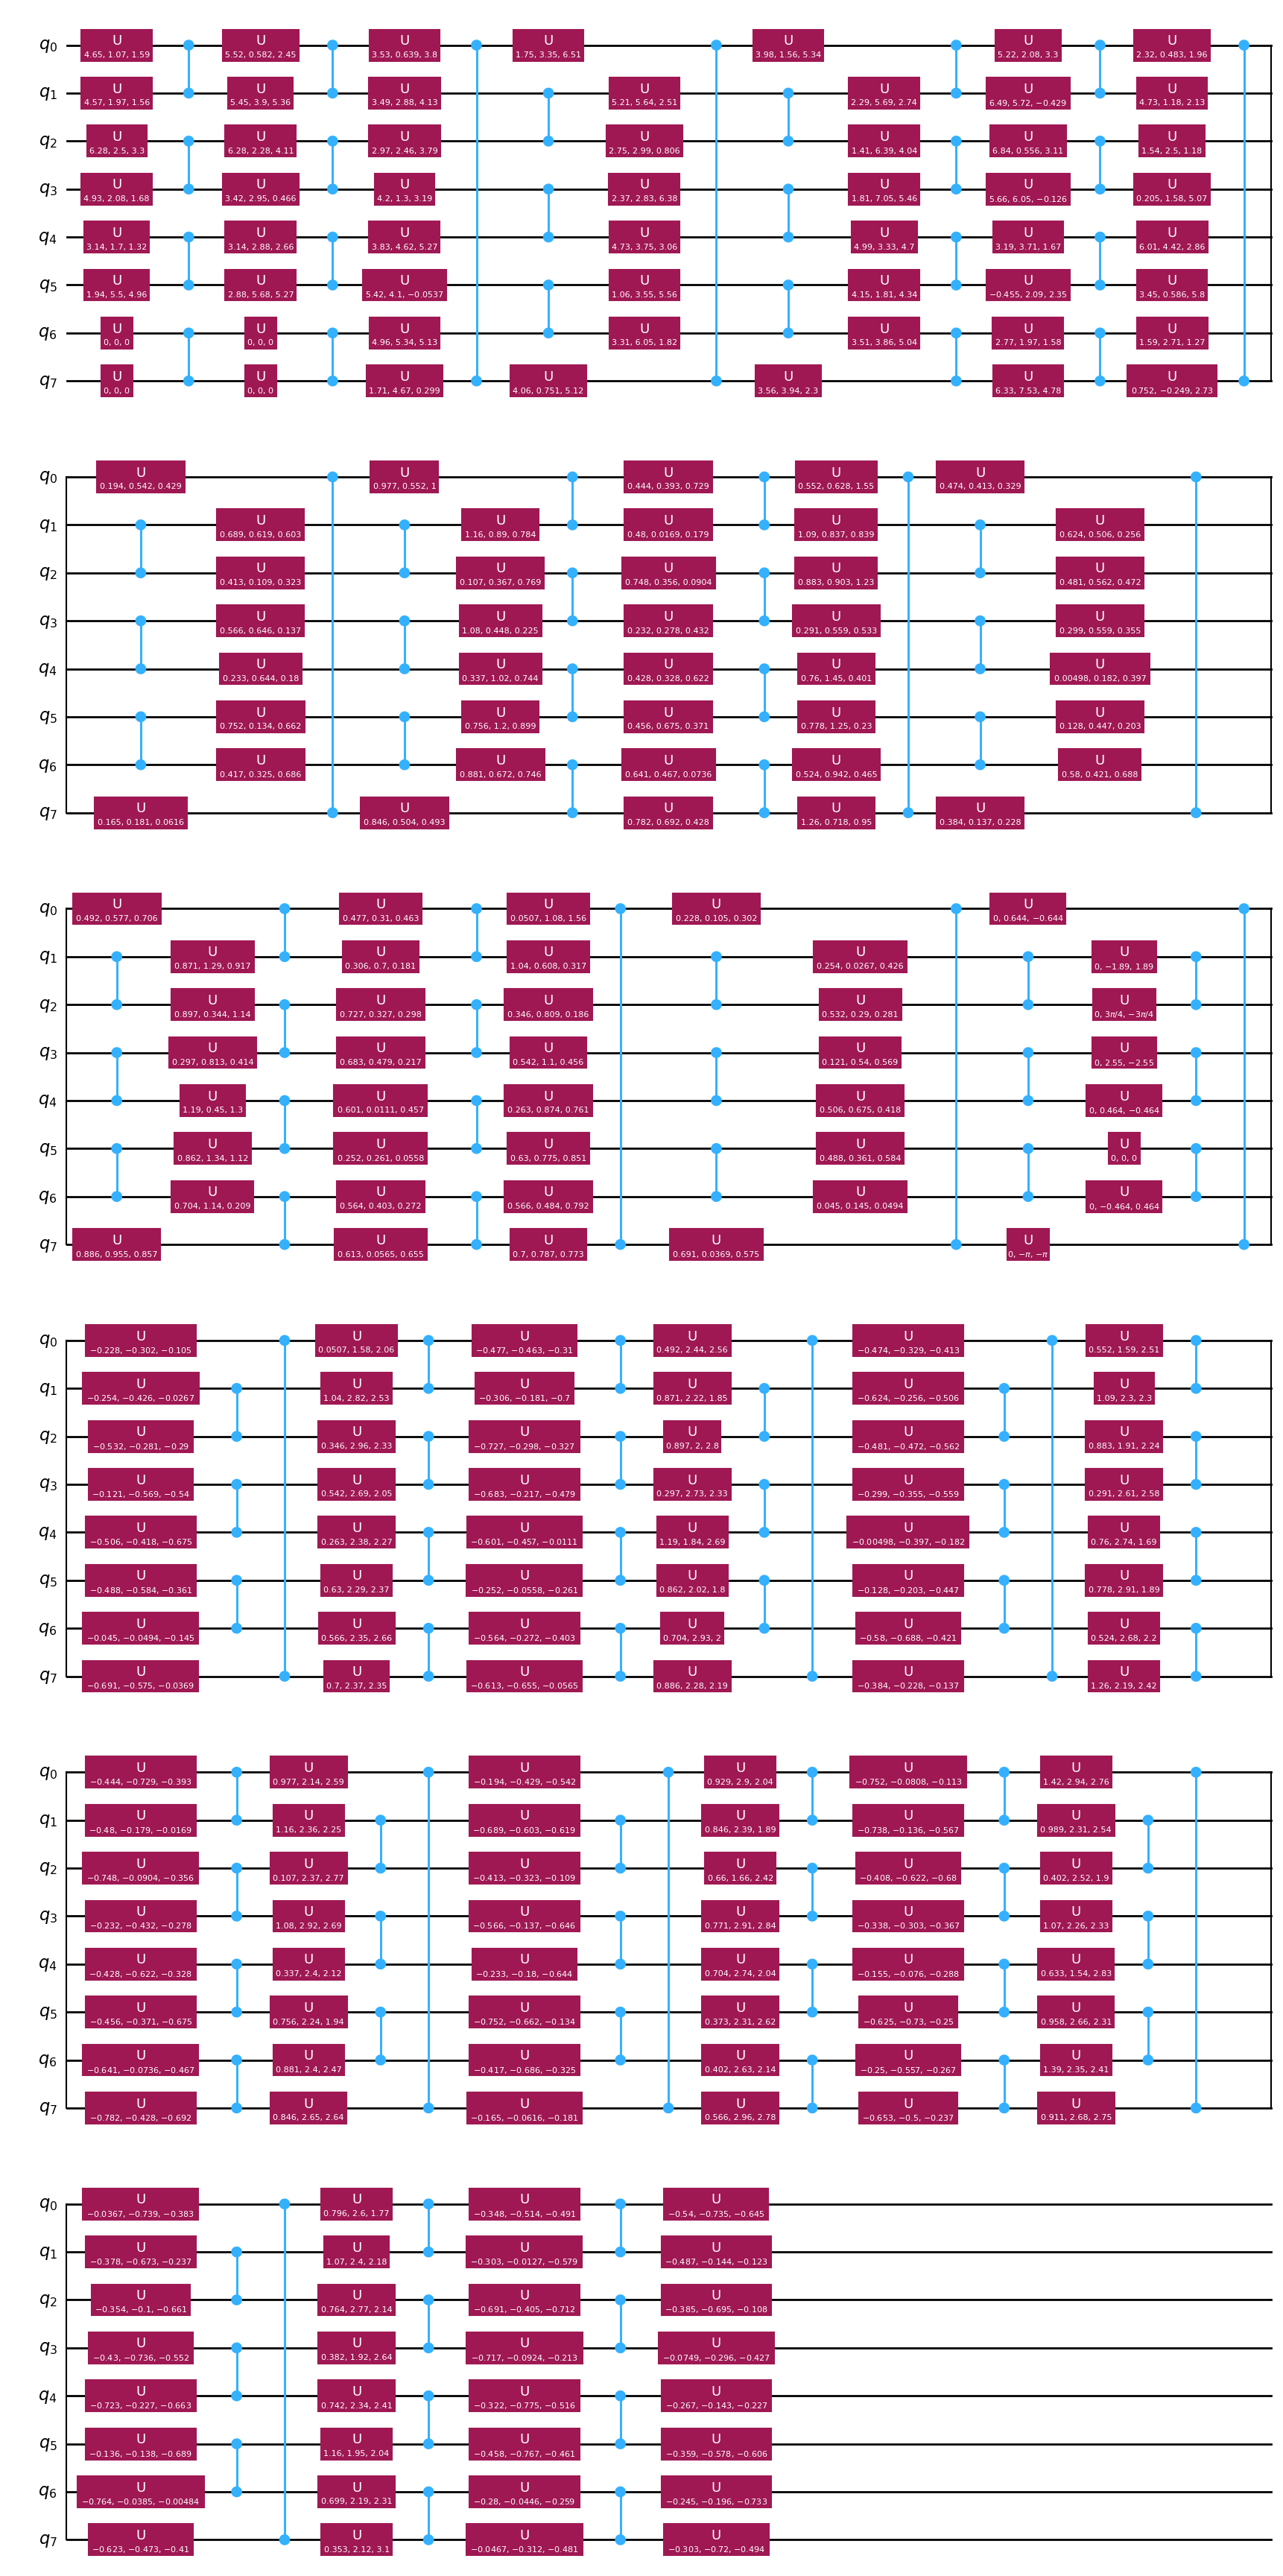

In [60]:
qc_mod.draw('mpl')

In [61]:
block_devs

[0.023476336015764473,
 0.02284349022174928,
 0.00959551789985754,
 0.014546912021280878]

In [62]:
simulator = AerSimulator()
qc_mod_t = transpile(qc_mod, simulator)
qc_mod_t.measure_all()
result = simulator.run(qc_mod_t,shots = 10000).result()
counts_1 = result.get_counts(qc_mod_t)

In [63]:
top_10_MPS = sorted(counts_1.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

00000000 = 9111             | 00000000 = 9111
00000110 = 263              | 00000110 = 263
00001010 = 86               | 00001010 = 86
00111000 = 44               | 00111000 = 44
00000100 = 40               | 00000100 = 40
00110000 = 33               | 00110000 = 33
10000001 = 28               | 10000001 = 28
11000001 = 27               | 11000001 = 27
10000011 = 27               | 10000011 = 27
00001111 = 25               | 00001111 = 25
